The goal is to convert every usable H&E patch into a numerical image embedding:

`H&E patch → frozen image encoder → image embedding vector → saved embedding table/file`

This gives us the image-side features needed for contrastive learning.

The outputs should be:
- `data/embeddings/TENX95_image_embeddings.npy`
- `data/embeddings/TENX95_image_embedding_index.csv`

In [2]:
# Setup & plot libraries
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Machine LEarning libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Computer Vision libraries
from torchvision import models, transforms
from PIL import Image

# Function to detect the project root directory
def find_project_root(start_path=None, project_name="HistoGeneAlign"):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()

    for p in [start_path] + list(start_path.parents):
        if p.name == project_name:
            return p

    for p in [start_path] + list(start_path.parents):
        if (p / "data").exists() and (p / "notebooks").exists():
            return p

    raise RuntimeError("Could not find project root.")

# Defining the paths
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMBEDDING_DIR = PROJECT_ROOT / "data" / "embeddings"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

# Creating the necessary directories if they don't exist
EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Sample ID for the analysis
SAMPLE_ID = "TENX95"

# Constructing the path for the patch H5 file
PATCH_H5_PATH = RAW_DIR / "patches" / f"{SAMPLE_ID}.h5"

# Verification of the patch H5 file existing and its path
print("Patch H5 exists:", PATCH_H5_PATH.exists())
print("Patch H5 path:", PATCH_H5_PATH)

# Checking for GPU availability and setting the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

c:\Users\Hareen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patch H5 exists: True
Patch H5 path: C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\patches\TENX95.h5
Device: cuda


### Setting the patch dataset name

In [6]:
# Loading the patch dataset from the H5 file and inspecting its properties
PATCH_DATASET_NAME = "img"
with h5py.File(PATCH_H5_PATH, "r") as f:
    patches = f[PATCH_DATASET_NAME]
    print("Patch dataset:", PATCH_DATASET_NAME)
    print("Patch shape:", patches.shape)
    print("Patch dtype:", patches.dtype)

# Getting the number of patches from the dataset shape
N_PATCHES = patches.shape[0]
print("Number of patches:", N_PATCHES)

Patch dataset: img
Patch shape: (7592, 224, 224, 3)
Patch dtype: uint8
Number of patches: 7592


### Creating patch dataset class

In [7]:
# Defining a custom PyTorch dataset to load patches from the H5 file
class H5PatchDataset(Dataset):
    # Initialization method to set up the dataset with the H5 file path,
        # dataset name, and optional transformations
    def __init__(self, h5_path, dataset_name, transform=None):
        self.h5_path = str(h5_path)
        self.dataset_name = dataset_name
        self.transform = transform

        with h5py.File(self.h5_path, "r") as f:
            self.length = f[self.dataset_name].shape[0]

        self.h5_file = None
    
    # Method to return the length of the dataset
    def __len__(self):
        return self.length

    # Internal method to initialize the H5 file handle if it hasn't been opened
        # yet, ensuring that the 
    def _init_h5(self):
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")

    # Method to retrieve a patch by index, convert it to and image, and
        # apply any transformations if specified
    def __getitem__(self, idx):
        self._init_h5()

        patch = self.h5_file[self.dataset_name][idx]

        # Convert channel-first to channel-last if needed
        if patch.ndim == 3 and patch.shape[0] in [1, 3, 4]:
            patch = np.transpose(patch, (1, 2, 0))

        # Convert to uint8 if needed
        if patch.dtype != np.uint8:
            patch = patch.astype(np.float32)
            pmin, pmax = patch.min(), patch.max()

            if pmax > pmin:
                patch = 255 * (patch - pmin) / (pmax - pmin)

            patch = patch.astype(np.uint8)

        # Ensure RGB
        if patch.ndim == 2:
            patch = np.stack([patch] * 3, axis=-1)

        if patch.shape[-1] == 4:
            patch = patch[:, :, :3]

        image = Image.fromarray(patch).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "patch_index": idx,
            "image": image
        }

### Defining image transforms

In [8]:
# Defining the image transformations to resize, convert to tensor, and
    # normalize the patches for input into the CNN model
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Loading frozen ResNet-50 encoder

In [9]:
# Creating ResNet-50 model and loading pretrained weights
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Remove classification layer
image_encoder = nn.Sequential(*list(resnet.children())[:-1])

# Moving the model to the appropriate device and setting it to evaluation mode
image_encoder = image_encoder.to(device)
image_encoder.eval()

# Freezing the parameters of the image encoder to prevent them from being 
    # updated during any potential training or fine-tuning steps
for param in image_encoder.parameters():
    param.requires_grad = False

# Printing out the status of the loaded model and its output embedding dimension
print("Loaded frozen ResNet-50 encoder.")
print("Output embedding dimension: 2048")

Loaded frozen ResNet-50 encoder.
Output embedding dimension: 2048


### Creating DataLoader

In [11]:
# Creating the patch dataset to load the image patches from the H5 file, and
    # applying the defined transformations
patch_dataset = H5PatchDataset(
    h5_path=PATCH_H5_PATH,
    dataset_name=PATCH_DATASET_NAME,
    transform=image_transform
)

# Creating a DataLoader to efficiently load the patches in batches for processing
patch_loader = DataLoader(
    patch_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Printing out the size of the dataset to confirm it was loaded correctly
print("Dataset size:", len(patch_dataset))

Dataset size: 7592


### Extracting embeddings

In [12]:
# Creating empty lists to store the extracted image embeddings and their
    # corresponding patch indices for later use in analysis and alignment with
    # the spatial transcriptomics data
all_embeddings = []
all_patch_indices = []

# Iterating through the DataLoader to extract image embeddings for each patch
with torch.no_grad():
    for batch in tqdm(patch_loader, desc="Extracting image embeddings"):
        images = batch["image"].to(device)
        patch_indices = batch["patch_index"].numpy()

        feats = image_encoder(images)

        # Shape: B x 2048 x 1 x 1 → B x 2048
        feats = feats.squeeze(-1).squeeze(-1)

        all_embeddings.append(feats.cpu().numpy())
        all_patch_indices.extend(patch_indices.tolist())

# Concatenating the list of embeddings into a single array and converting the
    # patch indices list into a numpy array for easier handling in subsequent
    # analysis and alignment with the spatial transcriptomics data
image_embeddings = np.concatenate(all_embeddings, axis=0)
all_patch_indices = np.array(all_patch_indices)

# Printing out the shapes of the resulting image embeddings and patch indices
print("Image embeddings shape:", image_embeddings.shape)
print("Patch indices shape:", all_patch_indices.shape)

Extracting image embeddings: 100%|██████████| 119/119 [00:30<00:00,  3.89it/s]

Image embeddings shape: (7592, 2048)
Patch indices shape: (7592,)


### Saving the embeddings

In [13]:
# Defining the paths to save the embeddings
embedding_path = EMBEDDING_DIR / f"{SAMPLE_ID}_resnet50_image_embeddings.npy"
index_path = EMBEDDING_DIR / f"{SAMPLE_ID}_resnet50_image_embedding_index.csv"

np.save(embedding_path, image_embeddings)

# Creating a DataFrame to store the index information for the embeddings,
    # including the sample ID, patch indices, embedding path, encoder type,
    # and embedding dimension for easier reference and analysis
embedding_index = pd.DataFrame({
    "sample_id": SAMPLE_ID,
    "patch_index": all_patch_indices,
    "embedding_path": str(embedding_path),
    "encoder": "resnet50_imagenet",
    "embedding_dim": image_embeddings.shape[1]
})

# Saving the DataFrame to CSV
embedding_index.to_csv(index_path, index=False)

# Printing out the paths where the embeddings and the index CSV have been saved
print("Saved embeddings:", embedding_path)
print("Saved index:", index_path)

# Displaying the first five rows of the embedding index DataFrame
display(embedding_index.head())

Saved embeddings: C:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_image_embeddings.npy
Saved index: C:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_image_embedding_index.csv


,sample_id,patch_index,embedding_path,encoder,embedding_dim
0,TENX95,0,C:\Users\Hareen\Desktop\HistoGeneAlign\data\em...,resnet50_imagenet,2048
1,TENX95,1,C:\Users\Hareen\Desktop\HistoGeneAlign\data\em...,resnet50_imagenet,2048
2,TENX95,2,C:\Users\Hareen\Desktop\HistoGeneAlign\data\em...,resnet50_imagenet,2048
3,TENX95,3,C:\Users\Hareen\Desktop\HistoGeneAlign\data\em...,resnet50_imagenet,2048
4,TENX95,4,C:\Users\Hareen\Desktop\HistoGeneAlign\data\em...,resnet50_imagenet,2048


### Sanity Checks for the embeddings

Embedding matrix shape: (7592, 2048)
NaN count: 0
Inf count: 0
Norm min: 8.050652
Norm mean: 12.548729
Norm max: 17.748173


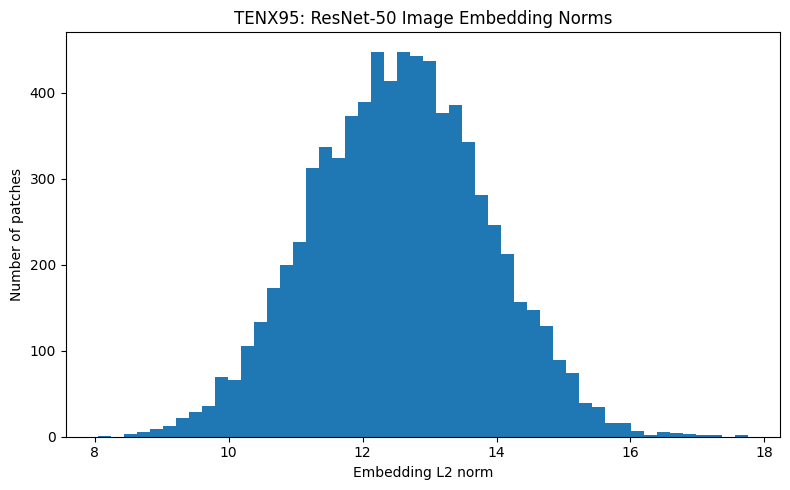

In [14]:
# Checking the shape, and precense of NaN or Inf values
print("Embedding matrix shape:", image_embeddings.shape)
print("NaN count:", np.isnan(image_embeddings).sum())
print("Inf count:", np.isinf(image_embeddings).sum())

# Calculating the L2 norms of the image embeddings to understand their distributions
embedding_norms = np.linalg.norm(image_embeddings, axis=1)

# Printing out the minimum, mean, and the maximum L2 norms
print("Norm min:", embedding_norms.min())
print("Norm mean:", embedding_norms.mean())
print("Norm max:", embedding_norms.max())

# Plotting the distribution of the L2 norms
plt.figure(figsize=(8, 5))
plt.hist(embedding_norms, bins=50)
plt.xlabel("Embedding L2 norm")
plt.ylabel("Number of patches")
plt.title(f"{SAMPLE_ID}: ResNet-50 Image Embedding Norms")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_resnet50_embedding_norms.png", dpi=300)
plt.show()

This histogram shows the L2 norm distribution of the frozen ResNet-50 image embeddings extracted from the TENX95 H&E patches.

Each patch was passed through the frozen ResNet-50 encoder, producing a 2,048-dimensional image feature vector. The L2 norm summarizes the overall magnitude of each embedding vector.

The embedding norms form a smooth, approximately bell-shaped distribution centered around 12 to 13 and most patch embeddings fall between approximately 10 and 15 with only a small number of lower-norm and higher-norm outliers.

This is a good sign. This means that the frozen image encoder is producing stable feature vectors acorss the patch set rather than producing collapsed, corrupted, or extreme embeddings